# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import time
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Convert labels from shape (n, 1) to (n,).
y_train = y_train.squeeze()
y_test = y_test.squeeze()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

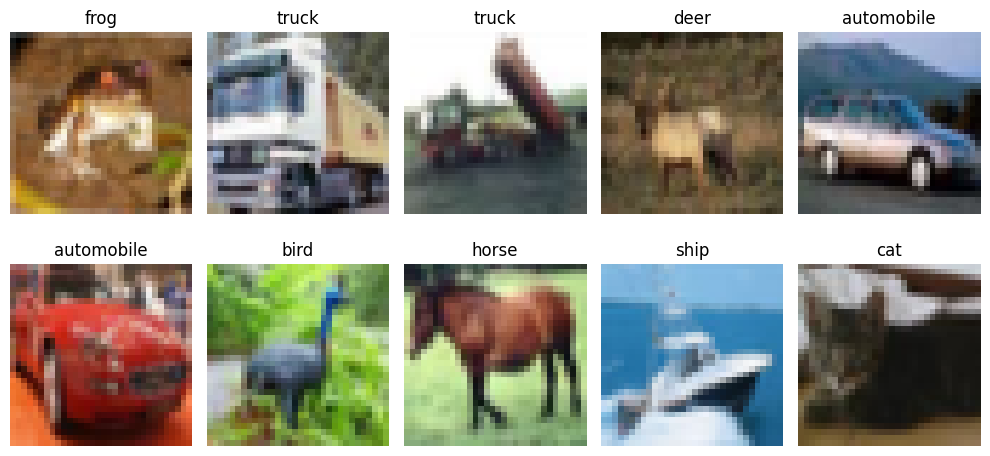

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()


# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
# Normalize both training and test images using the same rule.
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

# ANN needs one flat vector per image.
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("ANN input:", x_train_flat.shape)
print("CNN input:", x_train_norm.shape)


ANN input: (50000, 3072)
CNN input: (50000, 32, 32, 3)


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
# Beginner Task 1 completed: increased ANN depth.
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Beginner Tasks 3 and 4 completed: up to 20 epochs + EarlyStopping.
ann_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

ann_start_time = time.perf_counter()
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[ann_early_stopping]
)
ann_training_time = time.perf_counter() - ann_start_time


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.2522 - loss: 2.0210 - val_accuracy: 0.3170 - val_loss: 1.8754
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - accuracy: 0.3035 - loss: 1.8896 - val_accuracy: 0.3302 - val_loss: 1.8373
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3100 - loss: 1.8680 - val_accuracy: 0.3508 - val_loss: 1.8106
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3289 - loss: 1.8264 - val_accuracy: 0.3676 - val_loss: 1.7903
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3404 - loss: 1.8018 - val_accuracy: 0.3806 - val_loss: 1.7337
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.3514 - loss: 1.7824 - val_accuracy: 0.3836 - val_loss: 1.7329
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3559 - loss: 1.7709 - val_accuracy: 0.3814 - val_loss: 1.7439
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3577 - loss: 1.7574 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(
    x_test_flat, y_test, verbose=0
)

print(f"ANN Test Loss: {ann_test_loss:.4f}")
print(f"ANN Test Accuracy: {ann_test_acc * 100:.2f}%")


ANN Test Loss: 1.6227
ANN Test Accuracy: 42.66%


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
# Beginner Task 2 completed: filters progress from 32 to 64 to 128.
cnn_model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

cnn_start_time = time.perf_counter()
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[cnn_early_stopping]
)
cnn_training_time = time.perf_counter() - cnn_start_time


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 202ms/step - accuracy: 0.4394 - loss: 1.5636 - val_accuracy: 0.4912 - val_loss: 1.4256
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 195ms/step - accuracy: 0.5807 - loss: 1.1857 - val_accuracy: 0.6234 - val_loss: 1.0785
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 200ms/step - accuracy: 0.6479 - loss: 1.0059 - val_accuracy: 0.6546 - val_loss: 1.0049
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 197ms/step - accuracy: 0.6912 - loss: 0.8835 - val_accuracy: 0.6726 - val_loss: 0.9767
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 197ms/step - accuracy: 0.7236 - loss: 0.7881 - val_accuracy: 0.6806 - val_loss: 0.9464
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 196ms/step - accuracy: 0.7519 - loss: 0.7127 - val_accuracy: 0.7086 - val_loss: 0.9010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 195ms/step - accuracy: 0.7730 - loss: 0.6428 - val_accuracy: 0.7136 - val_loss: 0.9013
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 199ms/step - accuracy: 0.7960 -

In [8]:
# This works because x_test_norm is defined in the preprocessing cell.
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(
    x_test_norm, y_test, verbose=0
)

print(f"CNN Test Loss: {cnn_test_loss:.4f}")
print(f"CNN Test Accuracy: {cnn_test_acc * 100:.2f}%")


CNN Test Loss: 0.9353
CNN Test Accuracy: 69.88%


## 📈 Compare Learning Curves

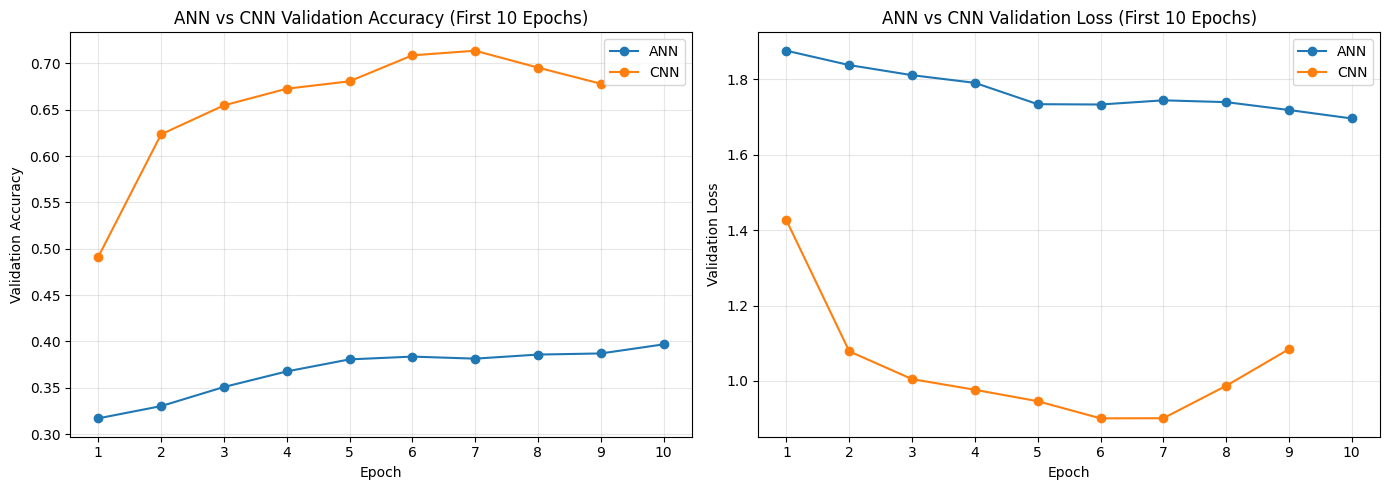

In [9]:
# Required validation comparison over the first 10 epochs.
comparison_epochs = 10
ann_epochs = min(comparison_epochs, len(ann_history.history['val_accuracy']))
cnn_epochs = min(comparison_epochs, len(cnn_history.history['val_accuracy']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    range(1, ann_epochs + 1),
    ann_history.history['val_accuracy'][:ann_epochs],
    marker='o', label='ANN'
)
axes[0].plot(
    range(1, cnn_epochs + 1),
    cnn_history.history['val_accuracy'][:cnn_epochs],
    marker='o', label='CNN'
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Accuracy")
axes[0].set_title("ANN vs CNN Validation Accuracy (First 10 Epochs)")
axes[0].set_xticks(range(1, 11))
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    range(1, ann_epochs + 1),
    ann_history.history['val_loss'][:ann_epochs],
    marker='o', label='ANN'
)
axes[1].plot(
    range(1, cnn_epochs + 1),
    cnn_history.history['val_loss'][:cnn_epochs],
    marker='o', label='CNN'
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Loss")
axes[1].set_title("ANN vs CNN Validation Loss (First 10 Epochs)")
axes[1].set_xticks(range(1, 11))
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
# Beginner Task 5 completed: a trainable CNN with data augmentation.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    data_augmentation,
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Optional extra experiment. Uncomment to include augmented CNN training:
# aug_early_stopping = EarlyStopping(
#     monitor='val_loss', patience=3, restore_best_weights=True
# )
# aug_history = aug_cnn_model.fit(
#     x_train_norm, y_train,
#     epochs=20,
#     validation_split=0.1,
#     batch_size=64,
#     callbacks=[aug_early_stopping]
# )
# aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
#     x_test_norm, y_test, verbose=0
# )


# 📊 Final Comparison Table

In [11]:
# Final output comparison dataframe using actual model results.
def create_result(model_name, model, history, test_loss, test_acc, train_time):
    train_accuracy = np.array(history.history['accuracy'])
    validation_accuracy = np.array(history.history['val_accuracy'])
    validation_loss = np.array(history.history['val_loss'])
    best_epoch_index = int(np.argmin(validation_loss))

    return {
        "Model": model_name,
        "Parameters": model.count_params(),
        "Epochs Trained": len(train_accuracy),
        "Best Epoch": best_epoch_index + 1,
        "Training Accuracy (%)": train_accuracy[best_epoch_index] * 100,
        "Best Validation Accuracy (%)": validation_accuracy.max() * 100,
        "Test Accuracy (%)": test_acc * 100,
        "Test Loss": test_loss,
        "Generalization Gap (%)": (
            train_accuracy[best_epoch_index] - test_acc
        ) * 100,
        "Training Time (Seconds)": train_time
    }


comparison = pd.DataFrame([
    create_result(
        "ANN", ann_model, ann_history,
        ann_test_loss, ann_test_acc, ann_training_time
    ),
    create_result(
        "CNN", cnn_model, cnn_history,
        cnn_test_loss, cnn_test_acc, cnn_training_time
    )
])

comparison = comparison.round({
    "Training Accuracy (%)": 2,
    "Best Validation Accuracy (%)": 2,
    "Test Accuracy (%)": 2,
    "Test Loss": 4,
    "Generalization Gap (%)": 2,
    "Training Time (Seconds)": 2
})

display(comparison)

winner = comparison.loc[
    comparison["Test Accuracy (%)"].idxmax(), "Model"
]
cnn_gain = (
    comparison.loc[
        comparison["Model"] == "CNN", "Test Accuracy (%)"
    ].iloc[0]
    - comparison.loc[
        comparison["Model"] == "ANN", "Test Accuracy (%)"
    ].iloc[0]
)

print(f"Best model based on test accuracy: {winner}")
print(f"CNN improvement over ANN: {cnn_gain:.2f} percentage points")


,Model,Parameters,Epochs Trained,Best Epoch,Training Accuracy (%),Best Validation Accuracy (%),Test Accuracy (%),Test Loss,Generalization Gap (%),Training Time (Seconds)
0,ANN,1738890,20,18,38.84,43.34,42.66,1.6227,-3.82,553.55
1,CNN,357706,9,6,75.19,71.36,69.88,0.9353,5.31,1267.93


Best model based on test accuracy: CNN
CNN improvement over ANN: 27.22 percentage points


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**